# EDA Notebook

08-06-2026

This notebook is used to take the `train.csv`, `val.csv`, and `test.csv` produced by the `prepare_data.py` script, and perform initial EDA. This notebook considers the case of a model that takes one image as input, not the multi-input model.

The following questions are addressed:
- [**How many images do you have?**](##how-many-images-are-there?) Rule of thumb: fewer than ~500 images means YOLO fine-tuning will struggle; you'll need aggressive augmentation.h
- [**What is the weight distribution?**](##what-is-the-weight-distribution?) Is it roughly normal, or are there rare very heavy/light animals? Imbalanced regression targets behave differently to balanced ones.
- [**What do the images look like?**](##what-do-the-images-look-like?) Are cows always full-body, or sometimes partial? Side-on, top-down, or mixed angles? This determines whether a single-stage classifier is appropriate or whether you need detection first.
- [**Are the images all the same size?**](##are-the-images-all-the-same-size?) Is every image of the 4 image dataset the same size?
- [**Breakdown by breed and colour**](##breakdown-by-breed-and-colour): looking at the amount of cows in each colour and breed
- [**Age, height, and weight correlations**](**age-height-weight-correlations): looking at correlations between age, heigh and weight
- [**Do you have bounding box annotations?**](##do-you-have-bounding-box-annotations?) This determines which YOLO approach you take (see Phase 3).
- [**Image quality and consistency?**](##image-quality-and-consistency?) Variable lighting, backgrounds, and camera distances all affect how much augmentation you need.

Findings from this notebook are added to the documentation in `docs/eda/index.md`

## Imports

In [ ]:
import os
from PIL import Image

from tqdm import tqdm
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

## How many images are there?

In [5]:
train_df = pd.read_csv("../data/processed/labels_train.csv")
val_df = pd.read_csv("../data/processed/labels_val.csv")
test_df = pd.read_csv("../data/processed/labels_test.csv")

print(f"Total number of cows: {len(set(train_df['sku'])) + len(set(val_df['sku'])) + len(set(test_df['sku']))}")
print(f"Total number of images: {len(train_df) + len(val_df) + len(test_df)}")
print(f"Does this equal to 4 images per cow: {len(train_df) + len(val_df) + len(test_df) == 4 * (len(set(train_df['sku'])) + len(set(val_df['sku'])) + len(set(test_df['sku'])))}")
print()
print(f"Number of training cows: {len(set(train_df['sku']))}")
print(f"Number of training images: {len(train_df)}")
print()
print(f"Number of validation cows: {len(set(val_df['sku']))}")
print(f"Number of validation images: {len(val_df)}")
print()
print(f"Number of testing cows: {len(set(test_df['sku']))}")
print(f"Number of testing images: {len(test_df)}")

Total number of cows: 513
Total number of images: 2052
Does this equal to 4 images per cow: True

Number of training cows: 359
Number of training images: 1436

Number of validation cows: 77
Number of validation images: 308

Number of testing cows: 77
Number of testing images: 308


## What is the weight distribution?

Minimum weight in kg: 150.0
Maximum weight in kg: 816.0
Median weight in kg: 239.0
Mode weight in kg: [210.0, 230.0]
Mean weight in kg: 256.029


Text(0, 0.5, 'Count')

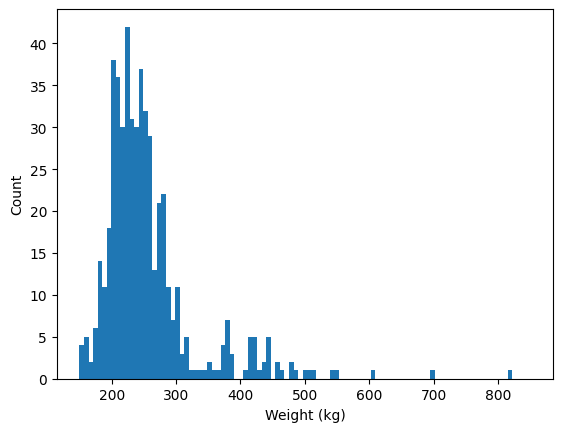

In [21]:
all_cows_df = pd.read_csv("../data/raw/dataset.csv")

print(f"Minimum weight in kg: {all_cows_df['weight_in_kg'].min()}")
print(f"Maximum weight in kg: {all_cows_df['weight_in_kg'].max()}")
print(f"Median weight in kg: {all_cows_df['weight_in_kg'].median()}")
print(f"Mode weight in kg: {list(all_cows_df['weight_in_kg'].mode())}")
print(f"Mean weight in kg: {all_cows_df['weight_in_kg'].mean():.3f}")

plt.hist(all_cows_df['weight_in_kg'], bins=np.linspace(150,850,100))
plt.xlabel("Weight (kg)")
plt.ylabel("Count")

## What do the images look like?

The below suggests that the 4 image indexes provide consistent views across all cows:
- Index 0: left view
- Index 1: front left view
- Index 2: rear left view
- Index 3: right view

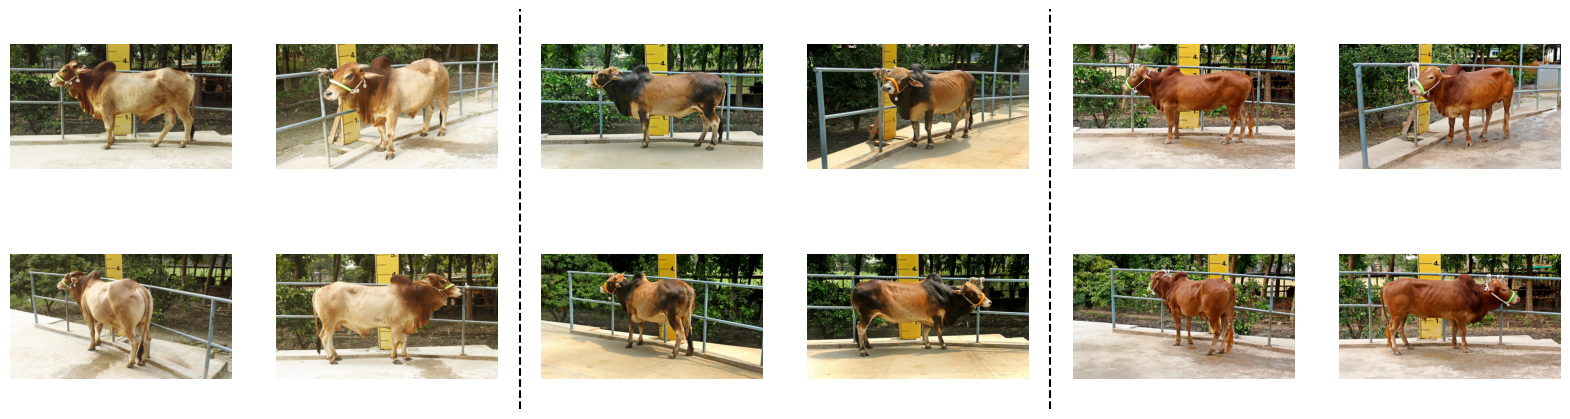

In [46]:
img00 = mpimg.imread("../data/raw/images/BLF 2340/BLF 2340_0.jpg")
img01 = mpimg.imread("../data/raw/images/BLF 2340/BLF 2340_1.jpg")
img02 = mpimg.imread("../data/raw/images/BLF 2340/BLF 2340_2.jpg")
img03 = mpimg.imread("../data/raw/images/BLF 2340/BLF 2340_3.jpg")

img10 = mpimg.imread("../data/raw/images/BLF2050/BLF2050_0.jpg")
img11 = mpimg.imread("../data/raw/images/BLF2050/BLF2050_1.jpg")
img12 = mpimg.imread("../data/raw/images/BLF2050/BLF2050_2.jpg")
img13 = mpimg.imread("../data/raw/images/BLF2050/BLF2050_3.jpg")

img20 = mpimg.imread("../data/raw/images/BLF2300/BLF2300_0.jpg")
img21 = mpimg.imread("../data/raw/images/BLF2300/BLF2300_1.jpg")
img22 = mpimg.imread("../data/raw/images/BLF2300/BLF2300_2.jpg")
img23 = mpimg.imread("../data/raw/images/BLF2300/BLF2300_3.jpg")

fig, ax = plt.subplots(2,6,figsize=(20,5))

ax[0,0].imshow(img00)
ax[0,0].axis('off')
ax[0,1].imshow(img01)
ax[0,1].axis('off')
ax[1,0].imshow(img02)
ax[1,0].axis('off')
ax[1,1].imshow(img03)
ax[1,1].axis('off')

ax[0,2].imshow(img10)
ax[0,2].axis('off')
ax[0,3].imshow(img11)
ax[0,3].axis('off')
ax[1,2].imshow(img12)
ax[1,2].axis('off')
ax[1,3].imshow(img13)
ax[1,3].axis('off')

ax[0,4].imshow(img20)
ax[0,4].axis('off')
ax[0,5].imshow(img21)
ax[0,5].axis('off')
ax[1,4].imshow(img22)
ax[1,4].axis('off')
ax[1,5].imshow(img23)
ax[1,5].axis('off')

from matplotlib.lines import Line2D
line = Line2D([0.38, 0.38], [0.1, 0.9], linestyle='dashed', color='black', linewidth=1.5, transform=fig.transFigure)
fig.lines.append(line)
line = Line2D([0.645, 0.645], [0.1, 0.9], linestyle='dashed', color='black', linewidth=1.5, transform=fig.transFigure)
fig.lines.append(line)

### Comparing visualisations of biggest cows to smallest cows

Want to ensure that the high end weights are not outliers, but actually due to larger cows

In [63]:
all_cows_df = pd.read_csv("../data/raw/dataset.csv")

lightest_cows = list(all_cows_df.nsmallest(3, 'weight_in_kg')['sku'])
heaviest_cows = list(all_cows_df.nlargest(3, 'weight_in_kg')['sku'])

Text(0.5, 0.98, 'Lightest cows')

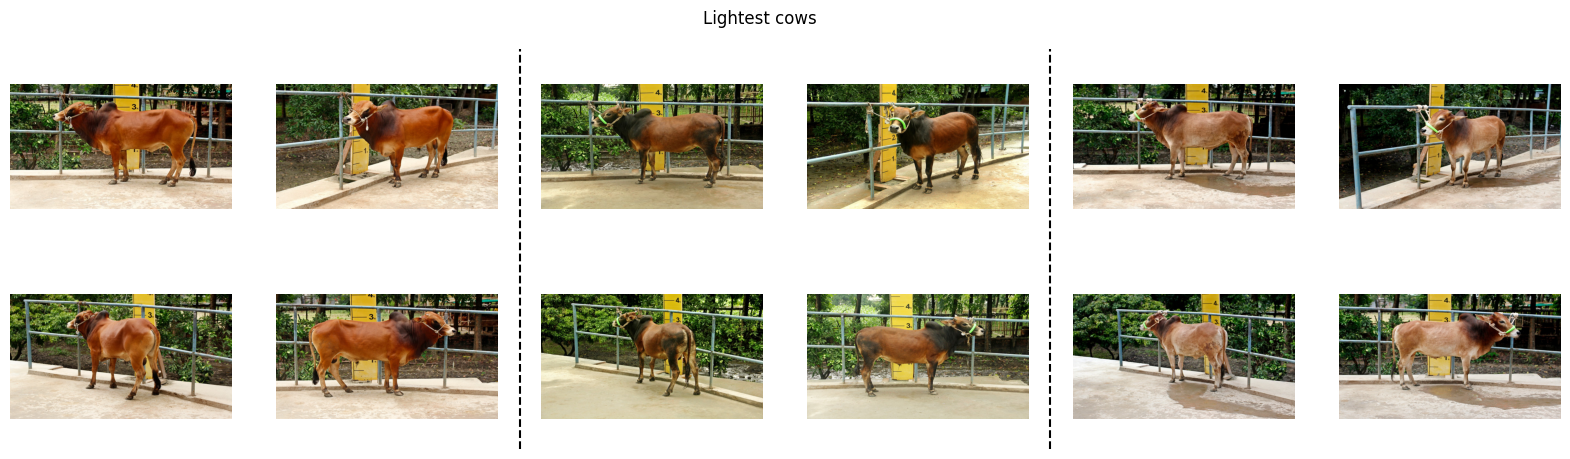

In [65]:
fig, ax = plt.subplots(2,6,figsize=(20,5))

for key,sku in enumerate(lightest_cows):
    img0 = mpimg.imread(f"../data/raw/images/{sku}/{sku}_0.jpg")
    img1 = mpimg.imread(f"../data/raw/images/{sku}/{sku}_1.jpg")
    img2 = mpimg.imread(f"../data/raw/images/{sku}/{sku}_2.jpg")
    img3 = mpimg.imread(f"../data/raw/images/{sku}/{sku}_3.jpg")

    ax[0,key*2].imshow(img0)
    ax[0,key*2].axis('off')
    ax[0,key*2+1].imshow(img1)
    ax[0,key*2+1].axis('off')
    ax[1,key*2].imshow(img2)
    ax[1,key*2].axis('off')
    ax[1,key*2+1].imshow(img3)
    ax[1,key*2+1].axis('off')

from matplotlib.lines import Line2D
line = Line2D([0.38, 0.38], [0.1, 0.9], linestyle='dashed', color='black', linewidth=1.5, transform=fig.transFigure)
fig.lines.append(line)
line = Line2D([0.645, 0.645], [0.1, 0.9], linestyle='dashed', color='black', linewidth=1.5, transform=fig.transFigure)
fig.lines.append(line)

fig.suptitle("Lightest cows")

Text(0.5, 0.98, 'Heaviest cows')

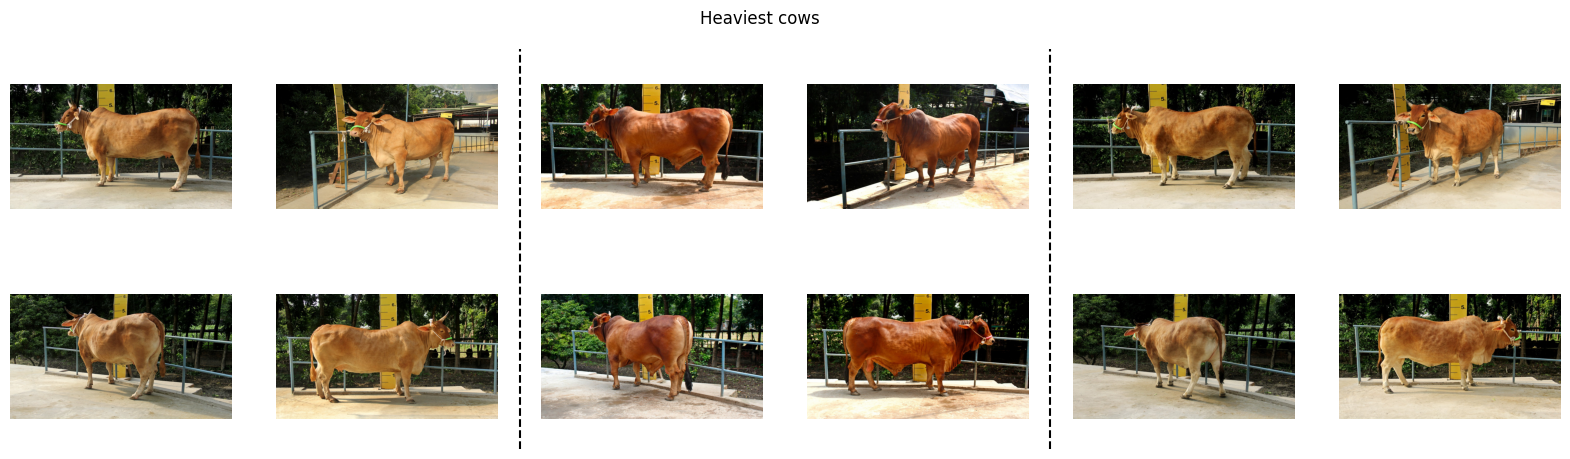

In [66]:
fig, ax = plt.subplots(2,6,figsize=(20,5))

for key,sku in enumerate(heaviest_cows):
    img0 = mpimg.imread(f"../data/raw/images/{sku}/{sku}_0.jpg")
    img1 = mpimg.imread(f"../data/raw/images/{sku}/{sku}_1.jpg")
    img2 = mpimg.imread(f"../data/raw/images/{sku}/{sku}_2.jpg")
    img3 = mpimg.imread(f"../data/raw/images/{sku}/{sku}_3.jpg")

    ax[0,key*2].imshow(img0)
    ax[0,key*2].axis('off')
    ax[0,key*2+1].imshow(img1)
    ax[0,key*2+1].axis('off')
    ax[1,key*2].imshow(img2)
    ax[1,key*2].axis('off')
    ax[1,key*2+1].imshow(img3)
    ax[1,key*2+1].axis('off')

from matplotlib.lines import Line2D
line = Line2D([0.38, 0.38], [0.1, 0.9], linestyle='dashed', color='black', linewidth=1.5, transform=fig.transFigure)
fig.lines.append(line)
line = Line2D([0.645, 0.645], [0.1, 0.9], linestyle='dashed', color='black', linewidth=1.5, transform=fig.transFigure)
fig.lines.append(line)

fig.suptitle("Heaviest cows")

## Are the images all the same size?

In [58]:
# write function to recursively open every jpg in the extracted dataset
all_dims = []
all_dims_counts = {}

all_folders = os.listdir("../data/raw/images/")
for folder in tqdm(all_folders):
    if os.path.isdir(f"../data/raw/images/{folder}"):
        all_files = os.listdir(f"../data/raw/images/{folder}")
        for file in all_files:
            if file[0] != '.':
                img = Image.open(f"../data/raw/images/{folder}/{file}")
                width, height = img.size
                dim = f"{width} x {height}"
                if dim not in all_dims:
                    all_dims.append(dim)
                    all_dims_counts[dim] = 1
                else:
                    all_dims_counts[dim] += 1

print(all_dims)
print(all_dims_counts)

100%|██████████| 1030/1030 [00:00<00:00, 3910.80it/s]

['800 x 450', '1200 x 675']
{'800 x 450': 520, '1200 x 675': 1536}


In [59]:
for i in range(len(all_dims)):
    print(f"Aspect ratio for {all_dims[i]}: {int(all_dims[i].split(' x ')[1]) / int(all_dims[i].split(' x ')[0])}:1")

Aspect ratio for 800 x 450: 0.5625:1
Aspect ratio for 1200 x 675: 0.5625:1


## Breakdown by breed and colour

In [70]:
all_cows_df = pd.read_csv("../data/raw/dataset.csv")

print(f"All breeds: {list(set(all_cows_df['breed']))}")
print(f"All colours: {list(set(all_cows_df['color']))}")

print()

for breed in list(set(all_cows_df['breed'])):
    print(breed)
    print(all_cows_df[all_cows_df['breed'] == breed]['color'].value_counts())
    print()

All breeds: ['HOSTINE_CROSS', 'SINDHI', 'PABNA_BREED', 'MIR_KADIM', 'BRAHMA', 'RED_CHITTAGONG', 'LOCAL', 'SAHIWAL']
All colours: ['RED', 'NON_RED']

HOSTINE_CROSS
color
NON_RED    29
RED         3
Name: count, dtype: int64

SINDHI
color
RED        37
NON_RED     1
Name: count, dtype: int64

PABNA_BREED
color
NON_RED    6
Name: count, dtype: int64

MIR_KADIM
color
NON_RED    2
Name: count, dtype: int64

BRAHMA
color
RED    2
Name: count, dtype: int64

RED_CHITTAGONG
color
RED    21
Name: count, dtype: int64

LOCAL
color
RED        187
NON_RED    166
Name: count, dtype: int64

SAHIWAL
color
RED        58
NON_RED     1
Name: count, dtype: int64



## Age Height Weight correlations

Age data is basically useless, as there are only 3 possible values.

Height to Weight correlation is as expected. No gross outliers to be worried about

Text(0, 0.5, 'weight_in_kg')

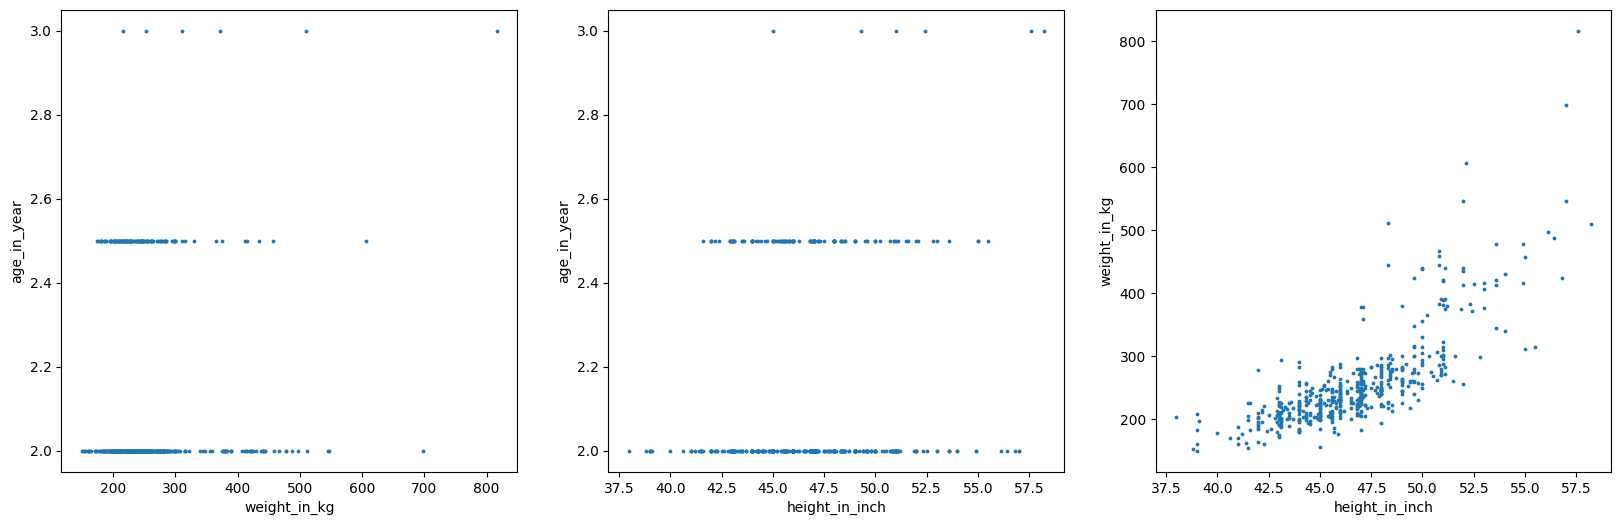

In [74]:
all_cows_df = pd.read_csv("../data/raw/dataset.csv")

fig, ax = plt.subplots(1,3,figsize=(20,6))

ax[0].scatter(all_cows_df['weight_in_kg'], all_cows_df['age_in_year'], s=3)
ax[0].set_xlabel("weight_in_kg")
ax[0].set_ylabel("age_in_year")

ax[1].scatter(all_cows_df['height_in_inch'], all_cows_df['age_in_year'], s=3)
ax[1].set_xlabel("height_in_inch")
ax[1].set_ylabel("age_in_year")

ax[2].scatter(all_cows_df['height_in_inch'], all_cows_df['weight_in_kg'], s=3)
ax[2].set_xlabel("height_in_inch")
ax[2].set_ylabel("weight_in_kg")

## Age Height Weight correlations

Noticeable outliers in the price:weight data, all with price less than 50,000 and no other connection.

Thought maybe they missed a zero on data entry, but it seems there is something else going on that I don't have the information to fix.

Fortunately, the (assumedly) correct data has very tight linear relation between price and weight, so any incorrect price data can be replaced with linear regression. However, since I don't know the reasons behind the incorrect data and because I don't need price data for any analysis, I am going to leave it be.

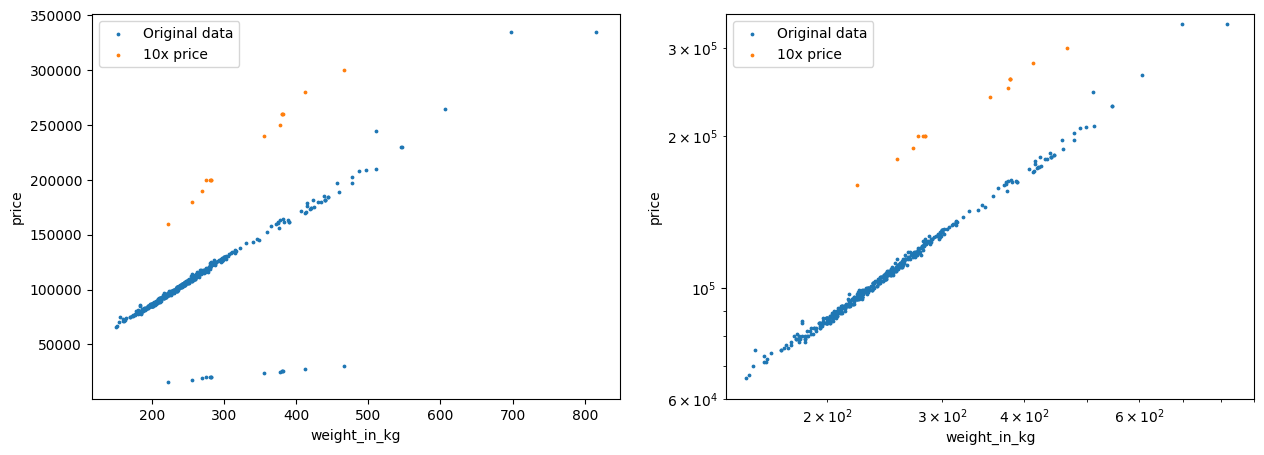

In [90]:
all_cows_df = pd.read_csv("../data/raw/dataset.csv")

fig, ax = plt.subplots(1,2,figsize=(15,5))

ax[0].scatter(all_cows_df['weight_in_kg'], all_cows_df['price'], s=3, label='Original data')
ax[0].scatter(all_cows_df[all_cows_df['price'] < 50000]['weight_in_kg'], 10 * all_cows_df[all_cows_df['price'] < 50000]['price'], s=3, c="tab:orange", label='10x price')
ax[0].legend()
ax[0].set_xlabel("weight_in_kg")
ax[0].set_ylabel("price")

ax[1].scatter(all_cows_df['weight_in_kg'], all_cows_df['price'], s=3, label='Original data')
ax[1].scatter(all_cows_df[all_cows_df['price'] < 50000]['weight_in_kg'], 10 * all_cows_df[all_cows_df['price'] < 50000]['price'], s=3, c="tab:orange", label='10x price')
ax[1].legend()
ax[1].set_xlabel("weight_in_kg")
ax[1].set_ylabel("price")
ax[1].set_xlim(140,900)
ax[1].set_ylim(60000,350000)
ax[1].set_xscale('log')
ax[1].set_yscale('log')

In [83]:
all_cows_df[all_cows_df['price'] < 50000]

,sku,sex,color,breed,feed,age_in_year,teeth,height_in_inch,weight_in_kg,price,size,images_count,yt_images_count,total_images
0,BLF 2340,MALE_BULL,RED,LOCAL,"['JUMBOO', 'LUCERNE', 'NAPIER', 'SILAGE', 'STR...",2.0,2,50.9,270.0,19000.0,MEDIUM,4,0,4
1,BLF 2342,MALE_BULL,NON_RED,LOCAL,"['JUMBOO', 'LUCERNE', 'NAPIER', 'SILAGE', 'STR...",2.0,2,52.0,256.0,18000.0,LARGE,4,31,35
90,BLF2089,MALE_BULL,NON_RED,LOCAL,"['JUMBOO', 'LUCERNE', 'NAPIER', 'SILAGE', 'STR...",2.0,2,47.0,275.0,20000.0,MEDIUM,4,31,35
116,BLF2115,MALE_BULL,RED,SINDHI,"['JUMBOO', 'LUCERNE', 'NAPIER', 'SILAGE', 'STR...",2.0,2,48.7,280.0,20000.0,MEDIUM,4,31,35
164,BLF2163,MALE_BULL,RED,SAHIWAL,"['JUMBOO', 'LUCERNE', 'NAPIER', 'SILAGE', 'STR...",2.0,2,47.5,282.0,20000.0,MEDIUM,4,31,35
167,BLF2166,MALE_BULL,RED,LOCAL,"['JUMBOO', 'LUCERNE', 'NAPIER', 'SILAGE', 'STR...",2.0,2,44.0,282.0,20000.0,MINIMUM,4,31,35
335,BLF2343,MALE_BULL,NON_RED,LOCAL,"['JUMBOO', 'LUCERNE', 'NAPIER', 'SILAGE', 'STR...",2.0,2,44.3,222.0,16000.0,MINIMUM,4,0,4
350,BLF2516,MALE_BULL,RED,HOSTINE_CROSS,"['JUMBOO', 'LUCERNE', 'NAPIER', 'SILAGE', 'STR...",2.0,2,50.0,355.0,24000.0,MEDIUM,4,31,35
365,BLF2531,MALE_BULL,RED,SINDHI,"['JUMBOO', 'LUCERNE', 'NAPIER', 'SILAGE', 'STR...",2.0,2,49.0,380.0,26000.0,MEDIUM,4,31,35
375,BLF2541,MALE_BULL,NON_RED,HOSTINE_CROSS,"['JUMBOO', 'LUCERNE', 'NAPIER', 'SILAGE', 'STR...",2.0,2,50.8,466.0,30000.0,MEDIUM,4,31,35


## Do you have bounding box annotations?

No. 

## Image quality and consistency?

From the limited set of images I have investigated, they appear to be standardised orientations/positions, location/background, lighting and distances.

Other than weight/size, the largest variation will be colour/breed.